# Rossmann Store Sales — Initial EDA

Loads and cleans the raw Kaggle data via `src/data_prep.py`, then looks at overall shape and quality issues found during initial inspection.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
from data_prep import load_raw, clean_store, fill_test_open, build_train_store

pd.set_option('display.max_columns', None)

In [2]:
train, test, store = load_raw()

store_clean = clean_store(store)
test_clean = fill_test_open(test)
train_store = build_train_store(train, store_clean)

train_store.shape, test_clean.shape, store_clean.shape

((1017209, 20), (41088, 8), (1115, 12))

In [3]:
train_store.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,CompetitionDistanceUnknown,CompetitionOpenUnknown
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,,0,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",0,0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",0,0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,,0,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,,0,0


In [4]:
test_clean.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


## Initial inspection summary (2026-08-03)

**Row counts**
- `train.csv`: 1,017,209 rows x 9 cols, all 1,115 stores, daily records Jan 1 2013 - Jul 31 2015.
- `test.csv`: 41,088 rows x 8 cols, Aug 1 - Sep 17 2015 (immediately after train ends, no overlap). Only 856 of the 1,115 stores appear.
- `store.csv`: 1,115 rows x 10 cols, one row per store.
- `sample_submission.csv`: 41,088 rows x 2 cols, matches test.csv 1:1 on `Id`.

**Closed-store / zero-sales pattern**
- 172,871 rows in train have `Sales == 0`.
- 172,817 of those are explained by `Open == 0` (the store was closed that day) — closed stores reliably report 0 sales.

**The 54 anomaly rows**
- The remaining 54 rows have `Open == 1` but `Sales == 0` — i.e. the store was marked open yet recorded no sales.
- Spread across 41 different stores and dates from 2013 through 2015, with no shared pattern: no state holidays, a mix of promo/non-promo days, a mix of weekdays.
- Likely genuine data-entry quirks rather than a systematic issue. Flagged as an edge case for modeling (e.g. exclude from training or treat as missing) rather than something a rule can clean up.

**Structural nulls in store.csv**
- 544 of 1,115 stores have `Promo2 == 0` (never opted into the continuity promo). For these, `Promo2SinceWeek`, `Promo2SinceYear`, and `PromoInterval` are null — this is *structural* (not applicable), not missing data. `clean_store()` fills these with `0` / `0` / `""` respectively.
- `CompetitionDistance` (3 nulls) and `CompetitionOpenSinceMonth`/`CompetitionOpenSinceYear` (354 nulls each) were investigated separately:
  - The 3 `CompetitionDistance` nulls (stores 291, 622, 879) also have null `CompetitionOpenSinceMonth`/`Year` — these stores have no competition data at all. `clean_store()` imputes `CompetitionDistance` with the median (~2,325m) and flags it via `CompetitionDistanceUnknown`.
  - The other 351 `CompetitionOpenSinceMonth`/`Year` nulls have a known `CompetitionDistance` — a competitor exists at a known distance, just an unrecorded open date, with no skew by `StoreType` or `Promo2`. Left null on purpose (flagged via `CompetitionOpenUnknown`), deferring the "months since competition opened" imputation decision to feature engineering rather than baking in an unverified assumption now.

**The Store 622 issue in test.csv**
- All 11 missing `Open` values in test.csv belong to a single store: Store 622 (rows for dates 2015-09-05 through 2015-09-17).
- `fill_test_open()` fills these with `1` (assumed open), since Store 622 has no other indication of being closed and Rossmann stores are open by default outside of holidays.

## Visual EDA

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("white")
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "text.color": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "font.family": "sans-serif",
    "axes.titleweight": "medium" if "medium" in plt.rcParams.get("font.weight", "") else "normal",
})

BLUE = "#2a78d6"   # categorical slot 1 — single-hue bars, since the x-axis already carries category identity
MUTED = "#c3c2b7"  # secondary/context series (raw daily total behind the smoothed trend)

# Categorical breakdowns (day of week, promo, store type, assortment) use only rows
# where the store was actually open — closed rows are structural zeros (see the
# closed-store pattern above) and would just dilute every category toward 0.
open_sales = train_store[train_store["Open"] == 1]

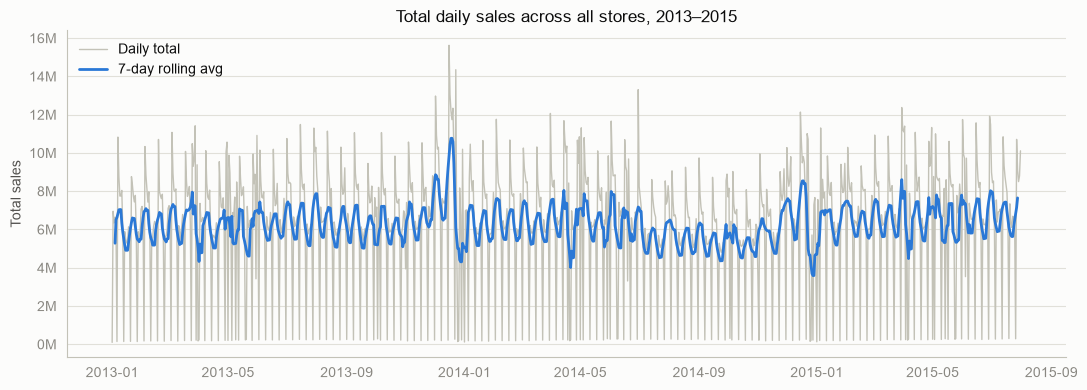

In [6]:
daily_sales = train_store.groupby("Date")["Sales"].sum()
rolling = daily_sales.rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(daily_sales.index, daily_sales.values, color=MUTED, linewidth=1, label="Daily total")
ax.plot(rolling.index, rolling.values, color=BLUE, linewidth=2, label="7-day rolling avg")
ax.set_title("Total daily sales across all stores, 2013\u20132015")
ax.set_ylabel("Total sales")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.0f}M"))
ax.grid(axis="y", linewidth=0.8)
ax.set_axisbelow(True)
sns.despine(ax=ax)
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

**What this shows:** total daily sales (summed across all 1,115 stores) hold fairly steady across the three years, with a mild upward drift (per-store mean sales rose from ~5,660 in 2013 to ~5,880 in 2015). Two patterns dominate the raw line:
- A strong **weekly cycle** — sharp weekly dips are Sundays, when nearly all stores are closed (see the day-of-week chart below for why).
- **Holiday spikes and troughs** — the five highest-volume days in the whole dataset are all in December 2013 (Dec 16 highest at ~15.6M), consistent with Christmas shopping; the lowest days are New Year's Day and Christmas Day each year, when most stores are closed.

The 7-day rolling average smooths out the weekly cycle so the underlying level and trend are easier to read.

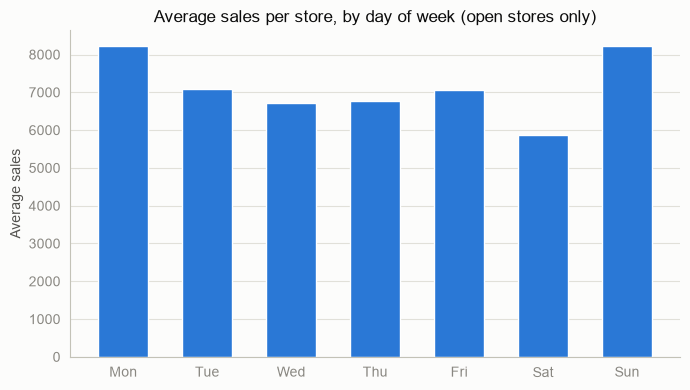

In [7]:
dow_labels = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}
dow_sales = open_sales.groupby("DayOfWeek")["Sales"].mean().rename(index=dow_labels)
dow_sales = dow_sales.reindex(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dow_sales.index, dow_sales.values, color=BLUE, width=0.6)
ax.set_title("Average sales per store, by day of week (open stores only)")
ax.set_ylabel("Average sales")
ax.grid(axis="y", linewidth=0.8)
ax.set_axisbelow(True)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

**What this shows:** among stores that were actually open, average sales per store are highest on **Monday** (~8,220) and, surprisingly, **Sunday** (~8,220) — almost identical. This is a real effect, not noise: only a small fraction of stores open on Sundays (see the near-zero Sunday dip in the time-series chart above, which reflects nearly all stores being *closed*), and the ones that do open sell just as much per store as the best weekday. Tuesday through Saturday sit in a lower, fairly flat band (~5,900\u20137,100), with Saturday the lowest of the open weekdays.

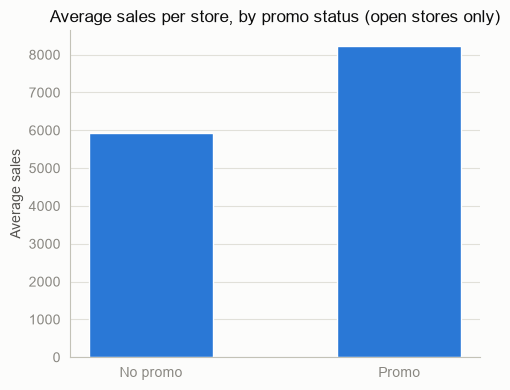

In [8]:
promo_sales = open_sales.groupby("Promo")["Sales"].mean().rename(index={0: "No promo", 1: "Promo"})

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(promo_sales.index, promo_sales.values, color=BLUE, width=0.5)
ax.set_title("Average sales per store, by promo status (open stores only)")
ax.set_ylabel("Average sales")
ax.grid(axis="y", linewidth=0.8)
ax.set_axisbelow(True)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

**What this shows:** average sales per store are about **39% higher on promo days** (~8,230 vs. ~5,930 on non-promo days), among open stores. This is a descriptive comparison, not a causal estimate — promo timing may correlate with other factors (e.g. which days/stores tend to run promos) — but the gap is large and consistent with promos being a meaningful sales driver, worth carrying into feature engineering.

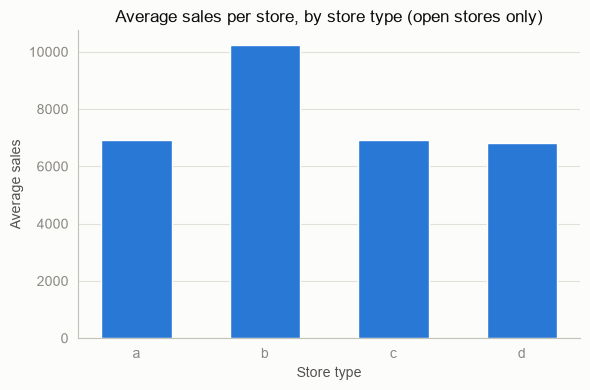

In [9]:
storetype_sales = open_sales.groupby("StoreType")["Sales"].mean().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(storetype_sales.index, storetype_sales.values, color=BLUE, width=0.55)
ax.set_title("Average sales per store, by store type (open stores only)")
ax.set_ylabel("Average sales")
ax.set_xlabel("Store type")
ax.grid(axis="y", linewidth=0.8)
ax.set_axisbelow(True)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

**What this shows:** store type **b** stands out with much higher average sales (~10,230) than types a, c, and d, which cluster tightly around 6,800\u20136,930. Type b is also by far the rarest — only 17 of 1,115 stores (vs. 602/148/348 for a/c/d) — so this looks like a small group of high-volume stores (plausibly larger-format or higher-traffic locations) rather than a broad category effect. Worth encoding `StoreType` as a model feature, but the tiny sample size for b means its effect estimate will be noisier than for the other types.

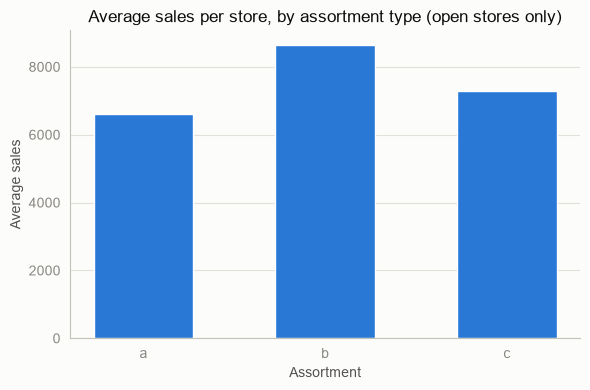

In [10]:
assortment_sales = open_sales.groupby("Assortment")["Sales"].mean().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(assortment_sales.index, assortment_sales.values, color=BLUE, width=0.55)
ax.set_title("Average sales per store, by assortment type (open stores only)")
ax.set_ylabel("Average sales")
ax.set_xlabel("Assortment")
ax.grid(axis="y", linewidth=0.8)
ax.set_axisbelow(True)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

**What this shows:** assortment **b** ("extra") averages the highest sales per store (~8,640), ahead of **c** (~7,300) and **a** (~6,620). Like store type b, assortment b is rare — only 9 of 1,115 stores — so this is a small, high-volume group rather than a broad pattern. Assortment a is the most common (444,909 open-store-day rows) and has the lowest average; c covers a large share too (391,271 rows) and sits in between on both count and average sales.